In [1]:
run_batchprocess = False

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os,glob
import re
import sys
sys.path.append('/root/capsule/code/')
from pprint import pprint 
from prepare_img_utils import *
from utils import get_paths

import scanpy as sc
import anndata as ad
import scvi
from registerCCF_util import *

def get_record(s):
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'), 
        'ox': s.get('anchoring')[0], 
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5], 
        'vx': s.get('anchoring')[6], 
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

# HOMEDIR = '/root/capsule//'
# paths = get_paths()
# print(paths.keys())

In [3]:
paths = get_paths()
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [4]:
paths['data_root']

PosixPath('/root/capsule/data')

In [5]:
scaling_factor=1/32; 
# all_file_path = paths['data_root'] /'image_xml/*.jpg'
all_file_path = os.path.join(paths['data_root'],'Nardone_2024_merfish_processing','image_xml', '*.jpg')
for f in glob.glob(all_file_path):
    print(os.path.basename(f).split('cell_img_')[1].split('.')[0])   # btw these images are 25um resolutions

MouseZM_ZM0
MouseF_F2
MouseZM_ZM7p1
MouseZM_ZM4
MouseEg_Eg2
MouseC_C4
MouseZM_ZM2
MouseF_F4
MouseC_C2
MouseZM_ZM5p1
MouseEg_Eg4
MouseZM_ZM1
MouseF_F3
MouseZM_ZM7p2
MouseEg_Eg3
MouseC_C5
MouseEg_B3
MouseZM_ZM3
MouseEg_Eg1
MouseC_C3
MouseZM_ZM6p1
MouseZM_ZM5p2
MouseEg_Eg5
MouseF_F1


In [6]:
all_file_path

'/root/capsule/data/Nardone_2024_merfish_processing/image_xml/*.jpg'

In [7]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_B3', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg4', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 24


In [8]:
len(slicename_all)

24

# batch process

In [9]:
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [10]:
run_batchprocess

False

In [11]:
HOMEDIR = str(paths['data_root'] / 'Nardone_2024_merfish_processing' )

In [12]:
HOMEDIR

'/root/capsule/data/Nardone_2024_merfish_processing'

In [13]:

from PIL import Image
if run_batchprocess:
    save_flag = False
    plotting_2d = False
    plotting_3d = False
    slicenum = ['1']
    slicenum=[int(i) for i in slicenum]

    registered_output = paths['registered_output']
    os.makedirs(registered_output, exist_ok=True)

    for name_of_slice in slicename_all:
        image_files=glob.glob(HOMEDIR + f'/image_xml/*{name_of_slice}.jpg')
        # load your file
        flat_name=[]  
        for i in image_files:
            result=re.search('(.*).jpg', i)
            n=result.group(1)+('_nl.flat')
            flat_name+=[n]
        assert(len(image_files)==1)
        with Image.open(image_files[0]) as im:
            w, h = im.size
        json_name=image_files 
        d = {'slicenum': slicenum, 'json_name': json_name,'flat_name':flat_name}
        name_df=pd.DataFrame(data=d)
        neurons=pd.read_csv(HOMEDIR+f'/filt_neurons_all/filt_neurons_{name_of_slice}.csv')
        neurons=neurons[neurons['slice'].isin(slicenum)]
        Max=neurons['x'].max()
        Min=neurons['y'].max()
        neurons['rescale_x']=neurons['x']*scaling_factor
        neurons['rescale_y']=neurons['y']*scaling_factor
        neurons['rescale_x'] = neurons['rescale_x'].astype(float)+500 # this was accounting for the padding that we created for the image
        neurons['rescale_y'] = neurons['rescale_y'].astype(float)+500

        # load visualign results 
        with open(HOMEDIR+f'/visualign_rez/{name_of_slice}.json') as f:
            vafile=json.load(f)
        details={s.get('filename'):s for s in vafile['slices']}
        assert(name_of_slice in list(details.keys())[0])

        rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
        neurons[['adjusted_x', 'adjusted_y']]= rez
        neurons_nl=neurons.copy()
        neurons_nl['clustid'] =neurons_nl['clustid'].astype(str)

        # load quickniii results 
        f = open(HOMEDIR+f'/quicknii_rez/quicknii_{name_of_slice}.json','r')
        data=json.loads(f.read())
        anchor=pd.DataFrame.from_records([get_record(s) for s in data['slices']])
        f.close()

        vox_dfs = []
        for slice_num, df in neurons_nl.groupby('slice'):
            quicknii_cord = get_quicknii_cord(slice_num, df,name_df,anchor,h,w) # Height and Width of image file
            vox_cord = get_vox_cord(quicknii_cord)
            vox_dfs += [vox_cord]    
        vox_df = pd.concat(vox_dfs)

        if save_flag:
            vox_df.to_csv(os.path.join(registered_output, f'registered_{name_of_slice}.csv'), index=False)

        # # optional plotting!
        # if plotting_3d:
        #     plot_df = vox_df.copy()
        #     fig = px.scatter_3d(plot_df, x='y_CCF', y='z_CCF', z='x_CCF', color='clustid')
        #     fig.update_traces(marker=dict(size=.5),selector=dict(mode='markers'))
        #     fig.update_scenes(aspectmode='data')
        #     fig.show()
        # elif plotting_2d:
        #     fig = px.scatter(plot_df, x='z_CCF', y='y_CCF', color='clustid')
        #     fig.update_traces(marker=dict(size=1),selector=dict(mode='markers'))
        #     fig.update_yaxes(scaleanchor='x', scaleratio=1)
        #     fig.show()
else:
    print('skip the batch process!')

skip the batch process!


In [14]:
paths['registered_output']

PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered')

#  now pull all these together 

In [15]:
paths['registered_output']

PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered')

In [16]:
reg_file_path = str(paths['registered_output']) +'/'
pprint(glob.glob(reg_file_path+'*'))

['/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseEg_B3.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM3.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseC_C3.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg1.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM5p2.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM6p1.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseF_F1.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg5.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseC_C5.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg3.csv',
 '/root/capsule/data/Nardone_2024_merfish_processing/registered/registere

In [17]:
paths

{'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing/registered'),
 'result': PosixPath('/root/capsule/results/merfish')}

In [18]:
slicename_all

['MouseC_C2',
 'MouseC_C3',
 'MouseC_C4',
 'MouseC_C5',
 'MouseEg_B3',
 'MouseEg_Eg1',
 'MouseEg_Eg2',
 'MouseEg_Eg3',
 'MouseEg_Eg4',
 'MouseEg_Eg5',
 'MouseF_F1',
 'MouseF_F2',
 'MouseF_F3',
 'MouseF_F4',
 'MouseZM_ZM0',
 'MouseZM_ZM1',
 'MouseZM_ZM2',
 'MouseZM_ZM3',
 'MouseZM_ZM4',
 'MouseZM_ZM5p1',
 'MouseZM_ZM5p2',
 'MouseZM_ZM6p1',
 'MouseZM_ZM7p1',
 'MouseZM_ZM7p2']

# load all the coords + genes

In [19]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    reg_points_path = reg_file_path + f'registered_{name}.csv'
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck = str(paths['data_root']) + '/Nardone_2024_merfish_processing/metadata/' + name + '/' + 'analyzed_data/*/region_*/'
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = str(paths['data_root']) + '/Nardone_2024_merfish_processing/metadata/'+ name + '/' + f'analyzed_data/*/{region_chosen}/'

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

In [20]:
thisdircheck

'/root/capsule/data/Nardone_2024_merfish_processing/metadata/MouseZM_ZM7p2/analyzed_data/*/region_0/'

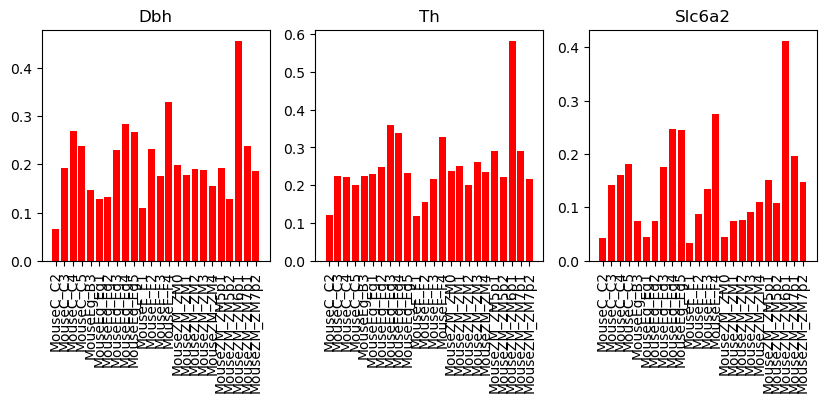

In [21]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [22]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [23]:
df = pd.concat((out_df_loc,out_df_gene),axis=1)

In [24]:
df.shape

(5473, 390)

In [25]:
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [26]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [27]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M'])
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [28]:
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)


# Boolean to indicaet if all three marker genes have to be expre
keptcellID = totalexpression>0
adata_mer = adata_mer[keptcellID]

In [29]:
totalexpression.shape

(5473,)

In [30]:
adata_mer.shape

(5473, 315)

In [31]:
np.ptp(adata_mer.obsm['spatial']), np.ptp(adata_mer.obsm['spatial'][:,1])

(np.float64(398.07117248269503), np.float64(248.49938469664033))

 # from here we do subsetting of cells. 
 - due to the machine difference we will load this results from the pre-saved csv file. 
 - the process used to run the subfiltering is frpm `potential doublets removal` but is omitted from here. 

In [32]:
selected_cells_path = paths['data_root']/'Nardone_2024_merfish_processing/selected_cell_ids.json'
with open(selected_cells_path) as f:
    selected_cells = json.load(f)
mask = adata_mer.obs_names.isin(selected_cells)

In [33]:
len(selected_cells)

2262

In [34]:
mask.sum()

np.int64(2262)

In [37]:

if not os.path.exists(paths['result']):
    os.makedirs(paths['result'])
    print(f"[created] {paths['result']}")
else:
    print(f"[exists] {paths['result']}")


adata_subset = adata_mer[mask].copy() 
filename = paths['result']/'adata_mer_subset_2_2k.h5ad'
adata_subset.write(filename)


... storing 'mouse_name' as categorical
... storing 'mouse_sex' as categorical


[exists] /root/capsule/results/merfish


/tmp/ipykernel_1815/3887699886.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(adata_subset.obsm['spatial'][:, 2], adata_subset.obsm['spatial'][:, 1],


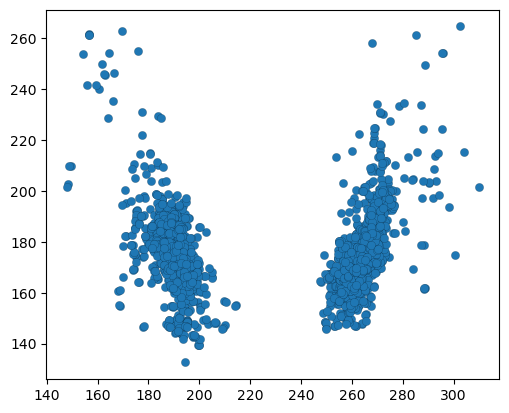

In [36]:
plt.scatter(adata_subset.obsm['spatial'][:, 2], adata_subset.obsm['spatial'][:, 1],  
            cmap='coolwarm',edgecolor='k', linewidth=0.1)
plt.gca().set_aspect('equal') 